# Freight rate prediction

This notebook is the full solution. Run every cell from top to bottom.


**What we do**
1. Load and explore the training data
2. Fix data-quality issues
3. Add simple features
4. Split by time and train a linear regression model
5. Predict validation loads and the December chart
6. Run `score.py`

## 0) Setup

Only pandas and numpy for the model. matplotlib is used by the official scorer.

In [1]:
from pathlib import Path
import subprocess
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
DATA = ROOT / "data"
print("working folder:", ROOT)

working folder: C:\Users\SYS\Downloads\Assesment


In [2]:
def find_file(*names):
    """Find a CSV in the project root or in data/."""
    for name in names:
        for folder in (ROOT, DATA):
            path = folder / name
            if path.is_file():
                return path
    raise FileNotFoundError("Could not find any of: " + ", ".join(names))

train_path = find_file("train-test.csv", "train_test.csv")
valid_path = find_file("validation.csv")
template_path = find_file("validation-predictions-template.csv", "validation_predictions_template.csv")
december_path = find_file("december-chart-inputs.csv", "december_chart_inputs.csv")

print("train:", train_path)
print("validation:", valid_path)
print("template:", template_path)
print("december:", december_path)

train: C:\Users\SYS\Downloads\Assesment\train-test.csv
validation: C:\Users\SYS\Downloads\Assesment\validation.csv
template: C:\Users\SYS\Downloads\Assesment\validation-predictions-template.csv
december: C:\Users\SYS\Downloads\Assesment\december-chart-inputs.csv


## 1) Load the files

In [3]:
train_raw = pd.read_csv(train_path)
valid_raw = pd.read_csv(valid_path)
template = pd.read_csv(template_path)
december_raw = pd.read_csv(december_path)

print("train rows:", len(train_raw), "cols:", len(train_raw.columns))
print("validation rows:", len(valid_raw))
print("template rows:", len(template))
print("december rows:", len(december_raw))
train_raw.head()

train rows: 48000 cols: 14
validation rows: 12000
template rows: 12000
december rows: 31


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


## 2) Explore the training data

Check types, missing values, duplicates, bad weights, outliers, and what actually predicts `posted_rate`.

In [4]:
print("column types")
print(train_raw.dtypes)
print("\nmissing values")
print(train_raw.isna().sum())
print("\nduplicate load_id:", int(train_raw["load_id"].duplicated().sum()))

column types
load_id          object
pickup           object
delivery         object
pickup_lat      float64
pickup_lon      float64
delivery_lat    float64
delivery_lon    float64
distance        float64
equipment        object
weight          float64
date             object
market_index    float64
quote_signal    float64
posted_rate     float64
dtype: object

missing values
load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

duplicate load_id: 0


In [5]:
w = pd.to_numeric(train_raw["weight"], errors="coerce")
print("non-positive weight rows:", int((w <= 0).sum()))
print("non-positive posted_rate rows:", int((train_raw["posted_rate"] <= 0).sum()))

dates = pd.to_datetime(train_raw["date"], errors="coerce")
print("date range:", dates.min().date(), "to", dates.max().date())
print("equipment counts:")
print(train_raw["equipment"].value_counts())

non-positive weight rows: 292
non-positive posted_rate rows: 0
date range: 2025-01-01 to 2025-10-31
equipment counts:
equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64


In [6]:
def count_iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    n = int(((series < low) | (series > high)).sum())
    return n, float(low), float(high)

print("IQR outlier counts")
for col in ["distance", "weight", "market_index", "quote_signal", "posted_rate"]:
    s = pd.to_numeric(train_raw[col], errors="coerce").dropna()
    n, low, high = count_iqr_outliers(s)
    print(f"  {col}: {n:,} outliers  (typical range {low:.2f} to {high:.2f})")

IQR outlier counts
  distance: 32 outliers  (typical range -1092.29 to 3288.21)
  weight: 424 outliers  (typical range 8973.00 to 53845.00)
  market_index: 0 outliers  (typical range 0.54 to 1.62)
  quote_signal: 1,956 outliers  (typical range 1.40 to 2.72)
  posted_rate: 260 outliers  (typical range -1867.24 to 6449.54)


In [7]:
print("correlation with posted_rate (distance is the main signal)")
num = train_raw.select_dtypes(include=[np.number])
corr = num.corr()["posted_rate"].sort_values(key=lambda x: x.abs(), ascending=False)
corr

correlation with posted_rate (distance is the main signal)


posted_rate     1.000000
distance        0.908519
delivery_lon   -0.257086
pickup_lon     -0.255058
delivery_lat   -0.091970
pickup_lat     -0.090873
quote_signal   -0.039858
weight          0.034840
market_index    0.034165
Name: posted_rate, dtype: float64

**Exploration notes**

- 48,000 training loads from Jan 1 to Oct 31, 2025.
- Missing `weight` (300) and `market_index` (374).
- 292 rows have negative weight (not realistic). Treat as a sign error.
- Distance correlation with rate is about 0.91. `market_index` and `quote_signal` are near 0, so we leave them out of the model.

## 3) Clean the data

- Parse dates
- Flip negative weights to positive with `abs()`
- Fill missing weight with the median for that equipment type

In [8]:
def clean_rows(df, weight_medians=None, fit=True):
    data = df.copy()
    data["date"] = pd.to_datetime(data["date"], errors="coerce")

    if fit:
        bad_dates = int(data["date"].isna().sum())
        if bad_dates > 0:
            print("dropped invalid dates:", bad_dates)
            data = data.dropna(subset=["date"]).copy()
        else:
            print("invalid dates: 0")

    data["weight"] = pd.to_numeric(data["weight"], errors="coerce").astype(float)
    n_neg = int((data["weight"] <= 0).sum())
    data.loc[data["weight"] <= 0, "weight"] = data.loc[data["weight"] <= 0, "weight"].abs()

    if fit:
        weight_medians = data.groupby("equipment")["weight"].median().to_dict()
        print("fixed non-positive weights:", n_neg)
        print("weight medians by equipment:", {k: round(v, 1) for k, v in weight_medians.items()})

    for eq, med in weight_medians.items():
        mask = (data["equipment"] == eq) & data["weight"].isna()
        data.loc[mask, "weight"] = med
    data["weight"] = data["weight"].fillna(float(np.median(list(weight_medians.values()))))
    return data, weight_medians

train_clean, w_med = clean_rows(train_raw, fit=True)
print("missing weight after clean:", int(train_clean["weight"].isna().sum()))

invalid dates: 0
fixed non-positive weights: 292
weight medians by equipment: {'Dry Van': 31444.0, 'Flatbed': 31532.5, 'Reefer': 31577.0}
missing weight after clean: 0


## 4) Simple features

We use distance, weight, equipment, and weekday.

We do **not** use month as a straight-line feature. A month slope fit on Jan–Aug would keep climbing into Nov–Dec, which is not how rates actually moved. Weekday still lets the December chart change when only the date changes.

In [9]:
def add_features(df):
    data = df.copy()
    data["day_of_week"] = data["date"].dt.dayofweek  # Monday=0 ... Sunday=6
    return data

train_clean = add_features(train_clean)
train_clean[["date", "day_of_week", "distance", "weight", "equipment", "posted_rate"]].head()

,date,day_of_week,distance,weight,equipment,posted_rate
0,2025-01-01,2,274.3,30658.0,Dry Van,645.41
1,2025-01-01,2,280.5,17555.0,Reefer,679.97
2,2025-01-01,2,967.8,31721.0,Dry Van,1802.54
3,2025-01-01,2,965.4,32333.0,Dry Van,1827.28
4,2025-01-01,2,541.9,35183.0,Reefer,1380.28


## 5) Time-based split (not random)

Training dates are Jan–Oct. The real prediction files are Nov–Dec (the future).

A random split would mix later dates into training and look too good. So we train on earlier dates and check on later dates.

In [10]:
data_sorted = train_clean.sort_values("date").reset_index(drop=True)
cut_idx = int(len(data_sorted) * 0.80)
cut_date = data_sorted.loc[cut_idx, "date"]

train_part = data_sorted[data_sorted["date"] <= cut_date].copy()
valid_part = data_sorted[data_sorted["date"] > cut_date].copy()

print("strategy: time-based 80/20")
print("cutoff date:", cut_date.date())
print("train rows:", len(train_part))
print("check rows:", len(valid_part))

strategy: time-based 80/20
cutoff date: 2025-08-31
train rows: 38477
check rows: 9523


## 6) Train a linear regression model

Why this model: freight rate is mostly “base amount + dollars per mile.” That is a straight line. The coefficients are easy to say out loud in a 2–3 minute video. No ensemble.

In [11]:
NUM_COLS = ["distance", "weight", "day_of_week"]
CAT_COLS = ["equipment"]

def make_x(df, dummy_cols=None):
    """Numbers stay numbers. Equipment becomes 0/1 columns."""
    nums = df[NUM_COLS].astype(float)
    dummies = pd.get_dummies(df[CAT_COLS], drop_first=False)
    if dummy_cols is None:
        dummy_cols = list(dummies.columns)
    else:
        dummies = dummies.reindex(columns=dummy_cols, fill_value=0)
    x = pd.concat([nums.reset_index(drop=True), dummies.reset_index(drop=True)], axis=1)
    return x, dummy_cols

def fit_model(x_df, y):
    """y ≈ intercept + beta1*x1 + beta2*x2 + ..."""
    x = x_df.to_numpy(dtype=float)
    x_i = np.column_stack([np.ones(len(x)), x])
    beta, _, _, _ = np.linalg.lstsq(x_i, y.to_numpy(dtype=float), rcond=None)
    return beta

def predict_rate(x_df, beta):
    x = x_df.to_numpy(dtype=float)
    x_i = np.column_stack([np.ones(len(x)), x])
    pred = x_i @ beta
    return np.clip(pred, 1.0, None)  # scorer requires positive rates

In [12]:
x_train, dummy_cols = make_x(train_part)
x_check, _ = make_x(valid_part, dummy_cols=dummy_cols)

beta = fit_model(x_train, train_part["posted_rate"])
check_pred = predict_rate(x_check, beta)

y_true = valid_part["posted_rate"].to_numpy(dtype=float)
err = y_true - check_pred
mae = float(np.mean(np.abs(err)))
rmse = float(np.sqrt(np.mean(err ** 2)))

print("model: linear regression (numpy least squares)")
print(f"MAE  on later dates:  {mae:.2f}")
print(f"RMSE on later dates:  {rmse:.2f}")
print("\ncoefficients")
names = ["intercept"] + list(x_train.columns)
for name, value in zip(names, beta):
    print(f"  {name:22s} {value:10.4f}")

model: linear regression (numpy least squares)
MAE  on later dates:  147.69
RMSE on later dates:  640.01

coefficients
  intercept                 76.1972
  distance                   1.8496
  weight                     0.0073
  day_of_week               -3.7751
  equipment_Dry Van       -131.5723
  equipment_Flatbed         53.1027
  equipment_Reefer         154.6668


## 7) Retrain on all labeled rows, then predict the 12,000 validation loads

In [13]:
x_full, dummy_cols = make_x(train_clean, dummy_cols=dummy_cols)
full_beta = fit_model(x_full, train_clean["posted_rate"])

valid_prep, _ = clean_rows(valid_raw, weight_medians=w_med, fit=False)
valid_prep = add_features(valid_prep)
x_valid, _ = make_x(valid_prep, dummy_cols=dummy_cols)
valid_pred = predict_rate(x_valid, full_beta)

pred_table = pd.DataFrame({
    "load_id": valid_prep["load_id"].astype(str),
    "predicted_rate": np.round(valid_pred, 2),
})

# Keep the template order and exact load_id list.
out = template[["load_id"]].copy()
out["load_id"] = out["load_id"].astype(str)
out = out.merge(pred_table, on="load_id", how="left")

if out["predicted_rate"].isna().any():
    raise ValueError("missing predictions for some load_ids")

out_path = ROOT / "validation_predictions.csv"
out.to_csv(out_path, index=False)
print("saved:", out_path)
print("rows:", len(out))
out.head()

saved: C:\Users\SYS\Downloads\Assesment\validation_predictions.csv
rows: 12000


,load_id,predicted_rate
0,TE-000001,869.25
1,TE-000002,4923.52
2,TE-000003,5449.07
3,TE-000004,4305.71
4,TE-000005,1823.41


## 8) Predict the 31 December chart rows

Same trained model. Keep the original 7 columns and column order. Lexington → Fort Wayne, 360 miles, Dry Van, 32,000 lb; only the date changes.

In [14]:
dec_prep, _ = clean_rows(december_raw, weight_medians=w_med, fit=False)
dec_prep = add_features(dec_prep)
x_dec, _ = make_x(dec_prep, dummy_cols=dummy_cols)
dec_pred = predict_rate(x_dec, full_beta)

december_out = december_raw.copy()
december_out["predicted_rate"] = np.round(dec_pred, 2)
keep = ["pickup", "delivery", "distance", "equipment", "weight", "date", "predicted_rate"]
december_out = december_out[keep]

DATA.mkdir(parents=True, exist_ok=True)
for path in [
    ROOT / "december-chart-inputs.csv",
    DATA / "december_chart_inputs.csv",
    DATA / "december-chart-inputs.csv",
]:
    december_out.to_csv(path, index=False)
    print("saved:", path)

december_out.head()

saved: C:\Users\SYS\Downloads\Assesment\december-chart-inputs.csv
saved: C:\Users\SYS\Downloads\Assesment\data\december_chart_inputs.csv
saved: C:\Users\SYS\Downloads\Assesment\data\december-chart-inputs.csv


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,844.48
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,841.35
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,838.22
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,835.09
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,831.96


## 9) Run the official scorer

This checks both output files and writes `scorer_results/candidate_december.png` for the report.

In [15]:
cmd = [
    sys.executable, "score.py",
    "--predictions", "validation_predictions.csv",
    "--december-predictions", "data/december_chart_inputs.csv",
]
result = subprocess.run(cmd, cwd=ROOT, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise SystemExit("score.py failed")

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results\candidate_december.png
Final validation metrics are calculated by Spotter after submission.



chart file: C:\Users\SYS\Downloads\Assesment\scorer_results\candidate_december.png


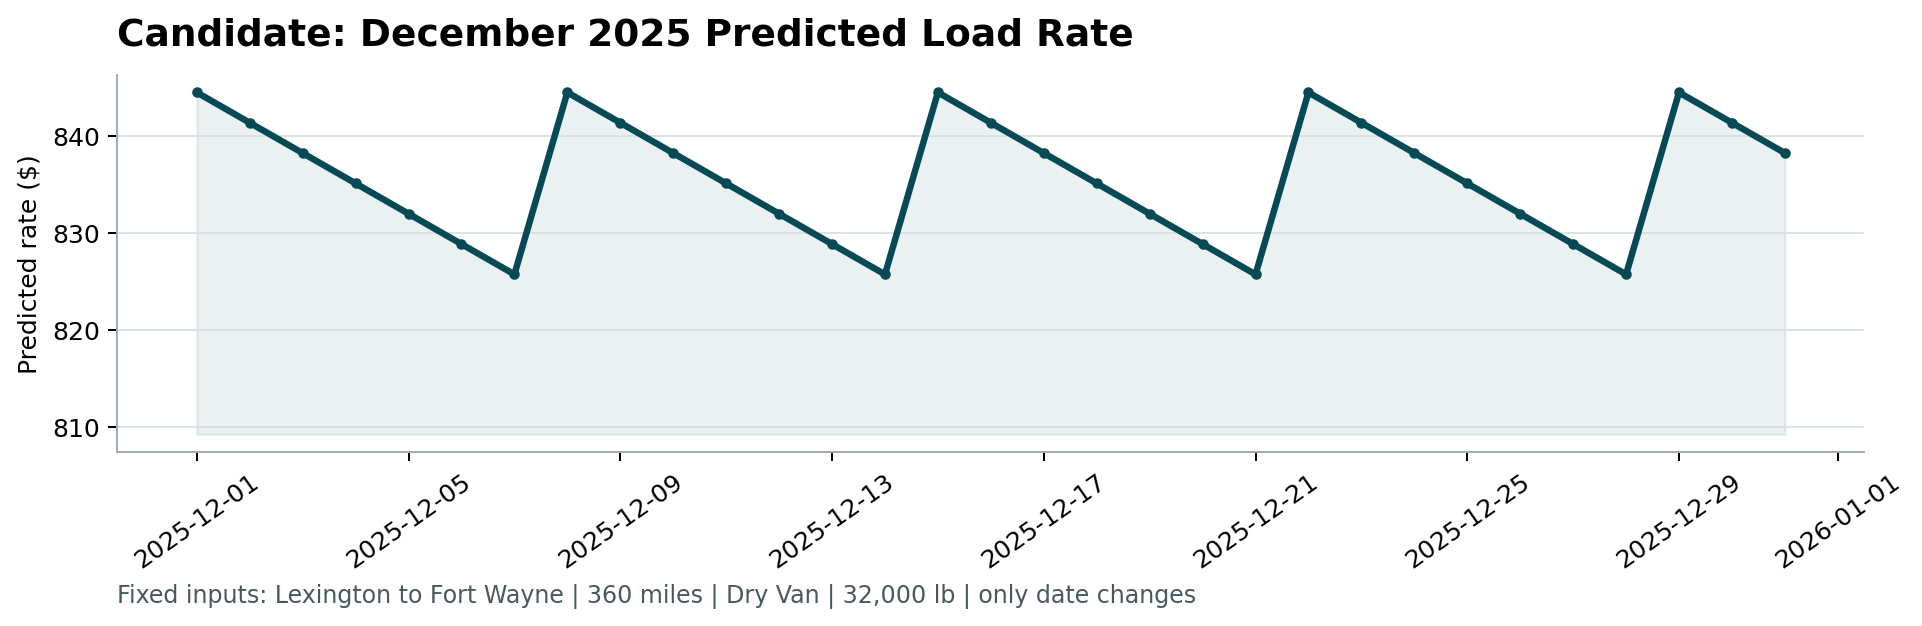

In [16]:
chart_path = ROOT / "scorer_results" / "candidate_december.png"
print("chart file:", chart_path)
display(Image(filename=str(chart_path)))